In [8]:
import nnunet_config
from examination import Examination
import SimpleITK as sitk
import pickle
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors

In [2]:
exam = Examination()

In [4]:
exam.read_dicom_series('./uploads/tmp8b0j_vrw')

ImageSeriesReader (0x55b862ebc7c0): Non uniform sampling or missing slices detected,  maximum nonuniformity:283.83



In [7]:
exam.read_dicom_metadata('./uploads/tmp8b0j_vrw')

In [8]:
exam.split_series()

In [9]:
exam.compute_segmentations()
"""
exam.read_segmentation('hip', '/home/simon/Downloads/hip_seg.nii.gz')
exam.read_segmentation('knee', '/home/simon/Downloads/knee_seg.nii.gz')
exam.read_segmentation('ankle', '/home/simon/Downloads/ankle_seg.nii.gz')
"""


Predicting image of shape torch.Size([1, 91, 499, 677]):
perform_everything_on_device: True


100%|██████████| 84/84 [00:34<00:00,  2.43it/s]


sending off prediction to background worker for resampling

Done with image of shape torch.Size([1, 91, 499, 677]):

Predicting image of shape torch.Size([1, 97, 475, 677]):
perform_everything_on_device: True


100%|██████████| 96/96 [00:36<00:00,  2.61it/s]


sending off prediction to background worker for resampling

Done with image of shape torch.Size([1, 97, 475, 677]):

Predicting image of shape torch.Size([1, 91, 570, 677]):
perform_everything_on_device: True


100%|██████████| 105/105 [00:39<00:00,  2.64it/s]


sending off prediction to background worker for resampling

Done with image of shape torch.Size([1, 91, 570, 677]):


"\nexam.read_segmentation('hip', '/home/simon/Downloads/hip_seg.nii.gz')\nexam.read_segmentation('knee', '/home/simon/Downloads/knee_seg.nii.gz')\nexam.read_segmentation('ankle', '/home/simon/Downloads/ankle_seg.nii.gz')\n"

In [10]:
exam.compute_torsional_alignment()

Marking landmarks on segmentation masks. hip_start = [ 13 341 194] hip_end = [ 13 365 114]
Marking landmarks on segmentation masks. hip_start = [ 12 338 126] hip_end = [ 12 365 206]


In [8]:
exam.get_torsion_values()

{'femoral_torsion_left': 17.389521431858718,
 'femoral_torsion_right': 18.6495387540514,
 'tibial_torsion_left': 23.606724362510164,
 'tibial_torsion_right': 35.71649921497118}

In [9]:
array = exam.marked_stack
img = sitk.GetImageFromArray(array)
sitk.WriteImage(img, '/home/simon/Downloads/stack_marked.nii.gz')

In [10]:
from morphometry.utils import correct_axis_ordering

In [11]:
img = correct_axis_ordering(exam.image)
sitk.WriteImage(img, '/home/simon/Downloads/stack.nii.gz')

In [12]:
exam.to_base64()

['...']

In [11]:
exam.save_to_pickle('/home/simon/Downloads/test.pkl')

In [111]:

with open('./data/xgswvb.pkl', 'rb') as f:
    exam2 = pickle.load(f)

In [112]:
layer = exam2.marked_stack[-21]

In [113]:
image = exam2.image_stack[-21]

In [114]:
np.unique(layer)

array([0, 2, 3, 4], dtype=uint8)

In [115]:
layer = layer.astype(np.int32) - 1
layer = np.where(layer < 0, 0, layer)

In [116]:
np.unique(layer)

array([0, 1, 2, 3], dtype=int32)

In [117]:
np.unique(np.random.randint(0, 4, (100, 100)))

array([0, 1, 2, 3])

In [118]:
cmap = colors.ListedColormap(['none', 'red', 'green', 'blue'])
bounds = [0, 1, 2, 3, 4]
norm = colors.BoundaryNorm(bounds, cmap.N)

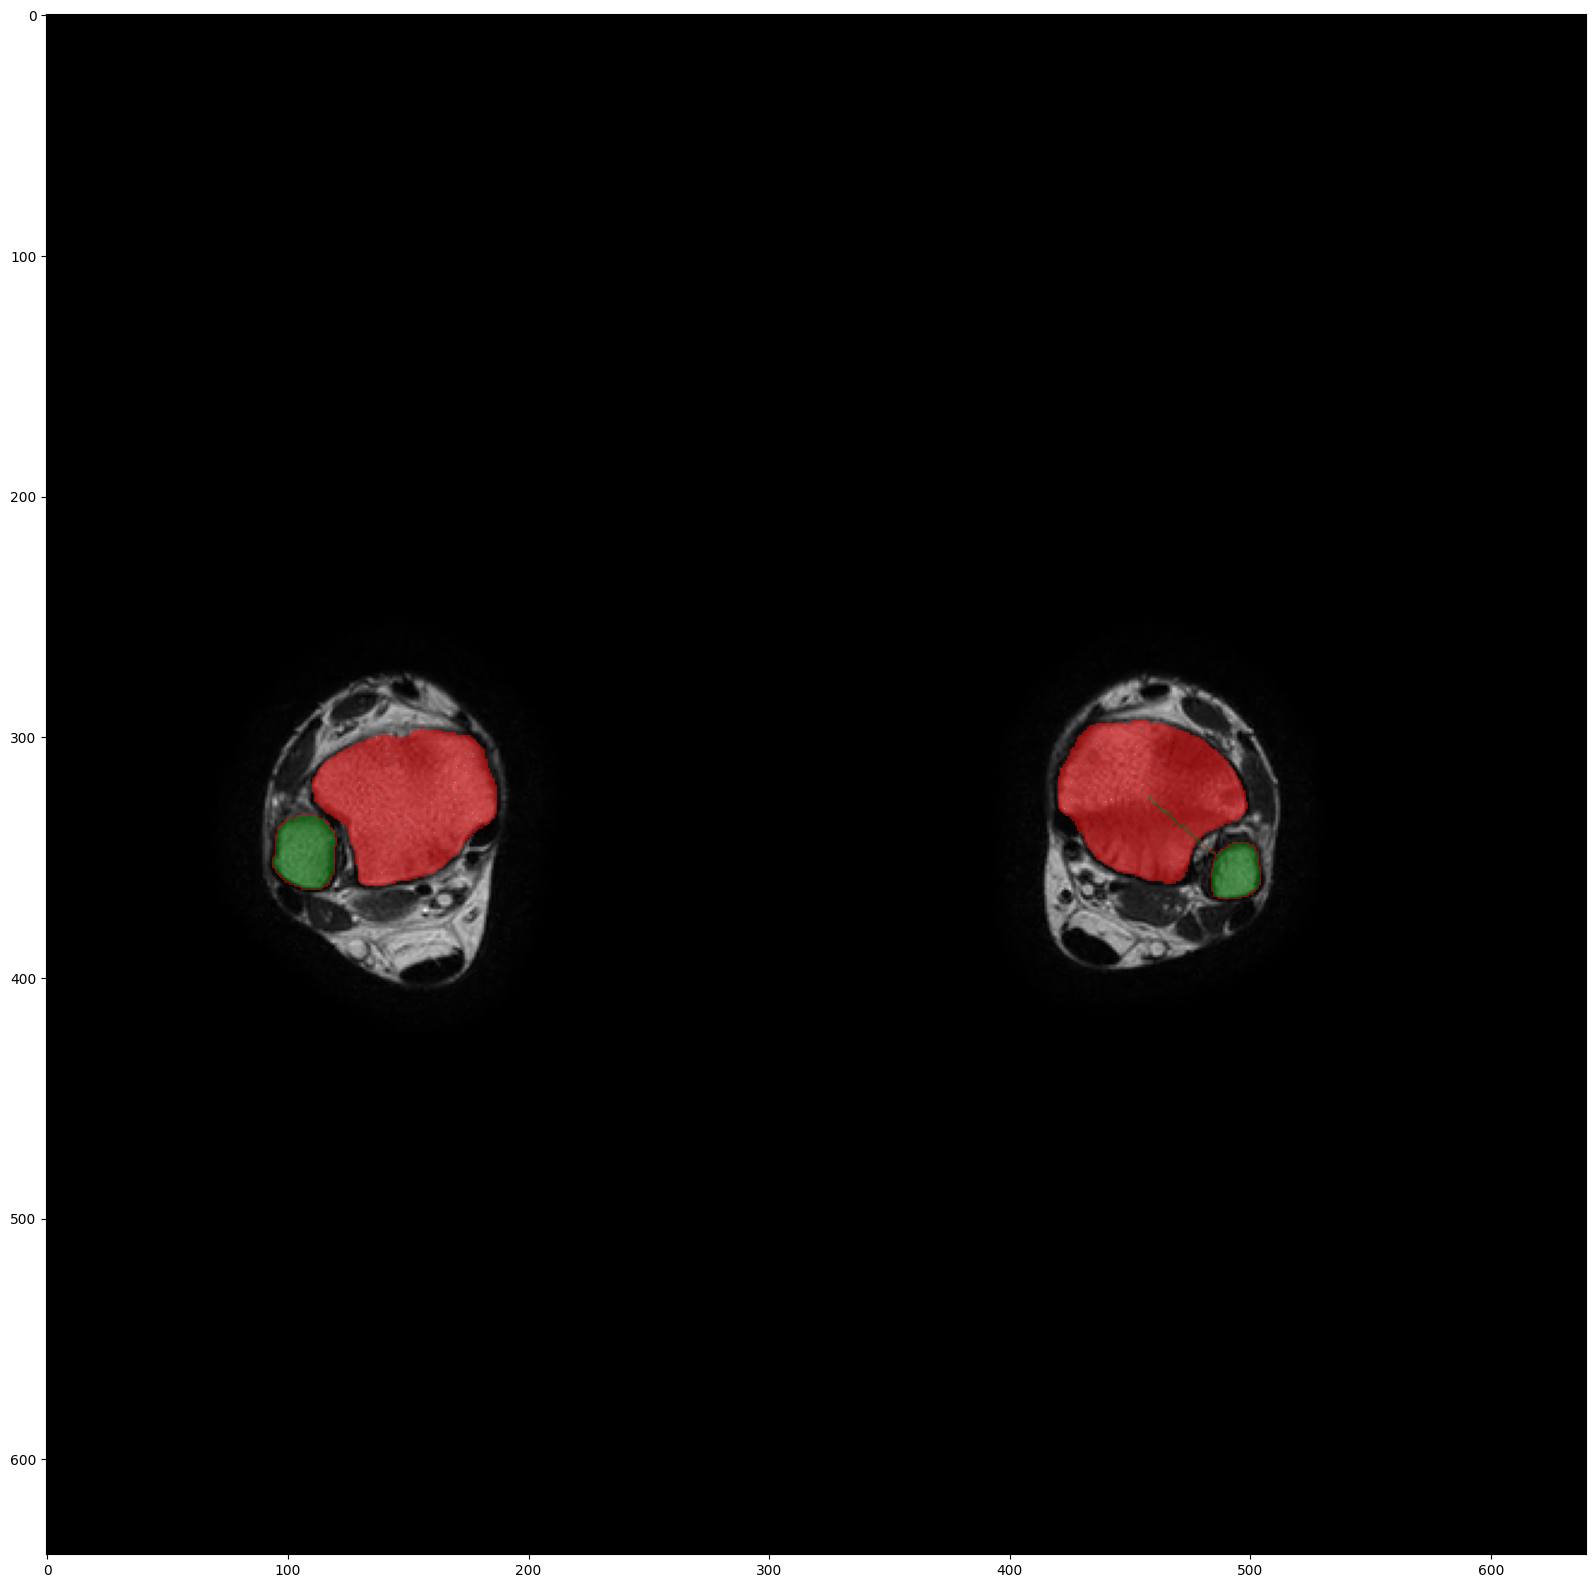

In [120]:
fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(image, cmap='grey')
ax.imshow(layer, cmap=cmap, norm=norm, alpha=.5)
plt.show()